# Checkerboard Learning with Tent Activation

We want to train a shallow network that can approximate a function learned from input samples.
In our case, our input values are two-dimensional $\vec x\in\mathbb [-2,2]^2$, and the target value is a single number $t\in\{-1,1\}$, and it should represent a checkerboard as shown below.

![The data distribution and its target value for 10000 random samples.](DL-Test-Exam-Targets.png)

Particularly, regions of size $1\times1$ shall be alternatingly assigned values $-1$ and $1$, such that two horizontally or vertically neighboring regions always have different targets.

Instead of using standard activation functions, we design our own `Tent` activation that we use in our network:

$$
\mathrm{tent}(a) = \begin{cases}1-a & \text{for } 0\leq a\leq 2 \\ 1+a & \text{for } -2 \leq a < 0\\ -1 & \text{elsewhere}\end{cases}
$$

A visual representation of the `Tent` activation function can be seen below.

![A visual display of the Tent activation function.](DL-Test-Exam-Tent.png)

Our designed network should contain two fully-connected layers, with a reasonable hidden layer dimension of $K$ neurons, and solely `Tent` activations.
The output should be restricted to be inside the range of $-1\leq y \leq 1$.
We train our network with batches of $B=1000$ samples, using stochastic gradient descent with an appropriate learning rate $\eta$.
We need to select an appropriate loss function.

## (a) Theory: Derivative (3 points)
Compute the derivative $\frac{\partial\mathrm{tent}(a)}{\partial a}$ of the activation function.

$$\frac{\partial \mathrm{tent}(a)}{\partial a} = \begin{cases}-1 & \text{for } 0\leq a\leq 2\\+1 & \text{for } -2 \leq a < 0 \\ 0 & \text{elsewhere}\end{cases}$$

## (b) Theory: Loss Function (3 points)
Which of the main loss functions discussed in the lecture would be applicable for this task? Are there any modifications to the target data that would be required for any of these functions to be applicable?

Two loss functions are typically possible here: MSE loss and Binary Cross-Entropy. 
The former can be applied without any modification. 
For the latter, the output needs to be transformed into $[0,1]$ range, for example, using the sigmoid activation, or by using `BCEWithLogitsLoss`. 
Other loss functions, such as L1 loss are also possible.

## (c) Coding: Target Values (3 points)
Implement a function that returns the target value $t$ for a given input vector $\vec x\in\mathbb R^2$. 
Make sure that this function can handle samples in a batch, i.e., $\mathbf X \in \mathbb R^{B\times 2}$. 

Note that this can be implemented in a one-line expression. 
Please check the visualization below and compare it with the plot provided above.

In [1]:
import torch

# The input x has dimensions Bx2, where B is the batch size, and we have two dimensions in our input
def target(x):
    # The target value should be in dimension B or Bx1
    # Which of the fields shall be considered 1 and which -1 is up to you, but they should represent a checker-board
    t = (torch.ceil(x[...,0]) + torch.ceil(x[...,1])) % 2 * 2 - 1
    return t

We provide the function to generate a batch of samples following the input distribution.
This function will call the `target` function from (c) and return the input and target tensors.

In [2]:
def batch(B, device = "cpu"):
    # generate B random data points in range [-2,2] in two dimensions.
    X = torch.distributions.Uniform(-2,2).sample([B,2]).to(device)
    # compute the targets for these samples
    T = target(X)
    # return both the inputs and the targets
    return X,T

We also provide a function to display the checkerboard samples.
You can run this cell to obtain a visualization, but this is not required.

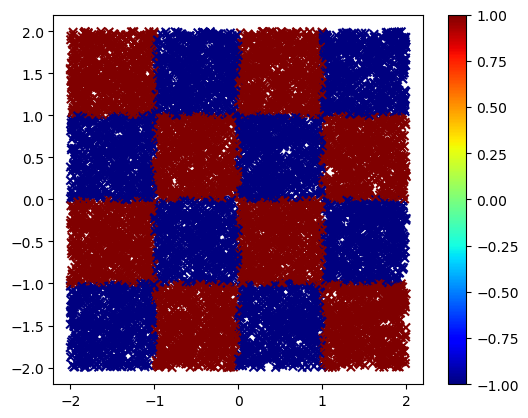

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from matplotlib import pyplot

# obtain 10000 samples and their targets
samples, targets = batch(10000)

# plot samples and targets in a scatter plot
pyplot.scatter(samples[:,0], samples[:,1], marker="x", c = targets.numpy(), cmap="jet")
# make the plot more beautiful
pyplot.axis("square")
_=pyplot.colorbar()

## (d) Coding: Tent Activation Function Implementation (2 points)

Implement the `tent` activation function by relying on automatic differentiation.
Make sure that the `tent` function can handle batches of data.

Note: The expression $0<a<2$ can be implemented with the function `torch.logical_and(0 < a, a < 2)`.

## (d) alternative
The original exam requested to implement an autograd function in PyTorch that implements our activation function including its derivative, for a total of 6 points. 
However, since we did not cover autograd functions in any exercise, this is optional here, and will not appear in the final exam.
Anyway, you can try to implement the `forward` pass as well as the `backward` pass. 
Make sure that all functions work on batches of activations. 
Remember that the output of the `backward` pass is the partial derivative of the loss with respect to the inputs of the forward pass. 
How many values need to be returned in both functions? 

In [4]:
# Alternative 1: Implement the tent activation function and rely on automatic differentiation
# You do not need to implement this function if you implement the Tent class below.
def tent(a):
    # compute the activation
    h = torch.maximum(1-torch.abs(a), torch.ones_like(a)*-1)
    return h

In [5]:
# Alternative 2: Implement the tent activation function as autograd function
# The Tent class shall be used as activation function
# You need to implement the forward and the backward pass
class Tent(torch.autograd.Function):
    @staticmethod
    # Compute the activation using the tent function as defined above
    def forward(ctx, a):
        # initialize output as -1
        output = torch.ones_like(a) * -1
        # assign 1-a for values between 0 and 2
        pos_indexes = torch.logical_and(0 < a, a < 2)
        output[pos_indexes] = 1-a[pos_indexes]
        # assign 1+a for values between -2 and 0
        neg_indexes = torch.logical_and(-2 < a, a <= 0)
        output[neg_indexes] = 1+a[neg_indexes]
        # save required information for the backward pass
        ctx.save_for_backward(pos_indexes, neg_indexes)
        # return the output(s) of the activation function
        return output

    # The input to this function is the partial derivative of the loss with respect to the output of the activation function
    def backward(ctx, dJ_dH):
        # get saved information from the backward pass
        pos_indexes, neg_indexes = ctx.saved_tensors
        # compute the partial derivative of the loss with respect to the input of forward
        dH_dA = torch.zeros_like(dJ_dH)
        dH_dA[pos_indexes] = -1.
        dH_dA[neg_indexes] = 1.
        # multiply the result with the dervative coming from above
        # this can be done in this simple way since the activation function is applied element-wise
        dJ_dA = dJ_dH * dH_dA
        return dJ_dA

# We will make use of this activation function.
# Please comment out this line (or do not run this cell) when you implement Alternative 1 above.
tent = Tent.apply

We provide a visualization for your (forward) implementation of the `tent` function or `Tent` class.
You can run this cell, but it is not required.

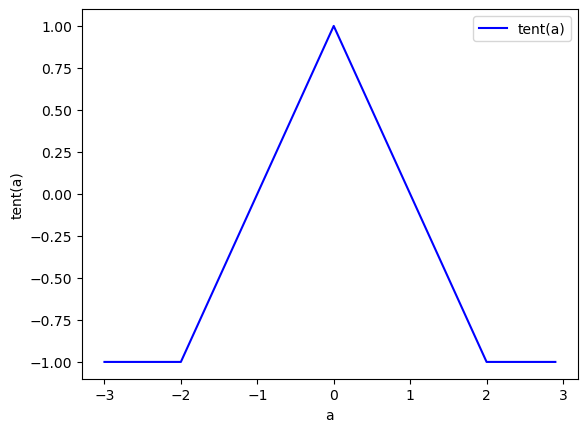

In [6]:
# create some input data
a = torch.arange(-3,3,0.1)
h = tent(a)

# plot the data
pyplot.plot(a, h, "b-", label="tent(a)")
# make the plot more beautiful
pyplot.xlabel("a")
pyplot.ylabel("tent(a)")
pyplot.legend()

## (e) Coding: Shallow Network Implementation (3 points)

Implement and instantiate a two-layer fully-connected network in `pytorch` with $D=2$ inputs, $O=1$ outputs and a reasonable number of hidden units $K$. 
Make use of the `tent` activation function whenever appropriate.

Note:

* There are several possibilities to implement the network. We will leave the freedom to choose to you.
* When the `tent` activation function cannot be implemented, it can also be replaced with an appropriate standard activation function.

In [ ]:
# decide for a reasonable number of hidden units
K = 16

# implement and instantiate the network
class Network(torch.nn.Module):
    def __init__(self, K):
        super(Network, self).__init__()
        self.fc1 = torch.nn.Linear(2,K)
        self.fc2 = torch.nn.Linear(K,1)

    def forward(self, x):
        # first layer
        h = tent(self.fc1(x))
        # second layer
        return tent(self.fc2(h))

network = Network(K)

## (f) Coding: Training Loop (4 points)

Instantiate an appropriate optimizer and an appropriate loss function. 
Make sure that possible required output adaptations according to (b) are implemented. 

Train the network for 1000 iterations. 
In each iteration, 10000 samples shall be randomly drawn from the input distribution. 
Report the average training loss after processing every 500 batches.

Note:

* You might need to re-run the cell above to reinitialize the network, when you changed the training loop implementation.
* Depending on your implementation, the training should not take more than a couple of seconds.

In [8]:
# possibly train on the GPU -- this is optional
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = network.to(device)

# instantiate optimizer and loss function
optimizer = torch.optim.SGD(network.parameters(), lr=0.001, momentum=0.9)
loss = torch.nn.MSELoss()

# iterate over 1000 training batches
for iteration in range(10000):
    # create a batch of 1000 samples
    X, T = batch(1000)

    # possibly change the alignment of the targets,
    # this is required when you observe an according warning
    # you might need to comment this out, depending on your target function implementation
    T = T.unsqueeze(1)

    # train the network on this batch
    Y = network(X.to(device))
    J = loss(Y, T.to(device))
    J.backward()
    optimizer.step()
    optimizer.zero_grad()


    # compute and print average loss after each 500 iterations
    if iteration % 500 == 499:
        print("Batch loss after", iteration+1, "iterations :", J.item())

Batch loss after 500 iterations : 1.0351983308792114
Batch loss after 1000 iterations : 1.0054175853729248
Batch loss after 1500 iterations : 1.0544649362564087
Batch loss after 2000 iterations : 1.0191166400909424
Batch loss after 2500 iterations : 0.9968385100364685
Batch loss after 3000 iterations : 1.0110924243927002
Batch loss after 3500 iterations : 0.9888373017311096


KeyboardInterrupt: 

We provide a final visualization of the network output after training.
Again, this cell is only for displaying purposes, and you do not need to run this cell.

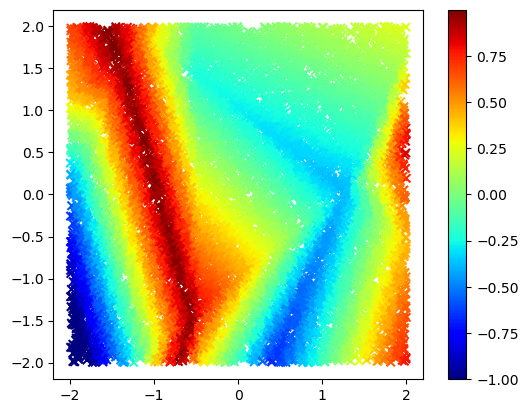

In [9]:
with torch.no_grad():
  samples, _ = batch(10000)
  outputs = network(samples.to(device)).cpu()

pyplot.scatter(samples[:,0], samples[:,1], marker="x", c = outputs, cmap="jet")
pyplot.axis("square")
_=pyplot.colorbar()